# FTES Data Cleaning and Preprocessing Pipeline

**Dataset:** DEMO-FTES Test 1 — 1-hour averaged telemetry  
**Period:** Dec 10, 2024 – Mar 24, 2025  
**Wells:** TL, TN, TC, TU, TS (collar / interval / bottom sections)  
**Measurements:** Flow rate (L/min), Pressure (psi), Temperature (°C via TEC thermocouples), Electrical Conductivity (EC), Packer depths (ft)

### Cleaning steps
1. Load and inspect data  
2. Handle missing / invalid values  
3. Detect and correct anomalies  
4. Feature engineering and phase labeling  
5. Normalize and scale features  
6. Train/test split and final validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries loaded.")

Libraries loaded.


## 1  Load and Inspect FTES Data

In [2]:
DATA_DIR = Path(r"c:\Users\tanx178\OneDrive - PNNL\2026_AI_competition\data")
CSV_FILE = DATA_DIR / "FTES-Full_Test_1hour_avg.csv"
OUTPUT_DIR = DATA_DIR / "cleaned"
OUTPUT_DIR.mkdir(exist_ok=True)

# ── load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_FILE, parse_dates=["Time"], index_col="Time")
df = df_raw.copy()

print("Shape          :", df.shape)
print("Index dtype    :", df.index.dtype)
print("Date range     :", df.index.min(), "→", df.index.max())
print("Total columns  :", len(df.columns))
print("\nColumn names:")
for c in df.columns:
    print(" ", c)

Shape          : (2609, 67)
Index dtype    : datetime64[us]
Date range     : 2024-12-10 21:00:00 → 2025-03-29 00:00:00
Total columns  : 67

Column names:
  Injection EC
  Net Flow
  TL Interval Flow
  TL Bottom Flow
  TL Collar Flow
  TL Interval EC
  TL Bottom EC
  TL Interval Pressure
  TL Bottom Pressure
  TL Packer Pressure
  TL-TEC-INT-U
  TL-TEC-INT-L
  TL-TEC-BOT-U
  TL-TEC-BOT-L
  TN Interval Flow
  TN Bottom Flow
  TN Collar Flow
  TN Interval EC
  TN Bottom EC
  TN Interval Pressure
  TN Bottom Pressure
  TN Packer Pressure
  TN-TEC-INT-U
  TN-TEC-INT-L
  TN-TEC-BOT-U
  TN-TEC-BOT-L
  TC Interval Flow
  TC Bottom Flow
  TC Collar Flow
  TC Interval EC
  TC Bottom EC
  TC Interval Pressure
  TC Bottom Pressure
  Injection Pressure
  TC Packer Pressure
  TC-TEC-INT-U
  TC-TEC-INT-L
  TC-TEC-BOT-U
  TC-TEC-BOT-L
  TU Interval Flow
  TU Bottom Flow
  TU Collar Flow
  TU Interval EC
  TU Bottom EC
  TU Interval Pressure
  TU Bottom Pressure
  PT 403
  TU Packer Pressure
  TU-TEC-I

In [3]:
# ── timestamp checks ──────────────────────────────────────────────────────────
expected_freq = "1h"
full_idx = pd.date_range(df.index.min(), df.index.max(), freq=expected_freq)
missing_ts = full_idx.difference(df.index)
duplicate_ts = df.index[df.index.duplicated()]

print(f"Expected hourly timestamps : {len(full_idx)}")
print(f"Actual rows                : {len(df)}")
print(f"Missing timestamps         : {len(missing_ts)}")
print(f"Duplicate timestamps       : {len(duplicate_ts)}")

if len(duplicate_ts):
    print("  → Dropping duplicates (keep first)")
    df = df[~df.index.duplicated(keep="first")]

# Reindex to a complete hourly grid so gaps become NaN rows
df = df.reindex(full_idx)
df.index.name = "Time"
print("\nReindexed shape:", df.shape)

Expected hourly timestamps : 2596
Actual rows                : 2609
Missing timestamps         : 103
Duplicate timestamps       : 116
  → Dropping duplicates (keep first)

Reindexed shape: (2596, 67)


In [4]:
# ── descriptive statistics before any cleaning ────────────────────────────────
print("=== Pre-cleaning descriptive statistics ===")
desc = df.describe().T
desc["range"] = desc["max"] - desc["min"]
desc[["count", "mean", "std", "min", "max", "range"]].round(4)

=== Pre-cleaning descriptive statistics ===


,count,mean,std,min,max,range
Injection EC,2493.0000,368.3023,9.2129,-30.4027,384.2765,414.6792
Net Flow,2493.0000,1.8302,1.0233,0.0066,7.3983,7.3917
TL Interval Flow,2493.0000,0.0063,0.0333,-1.6452,0.0777,1.7229
TL Bottom Flow,2493.0000,0.0010,0.0331,-1.6482,0.0466,1.6948
TL Collar Flow,2493.0000,0.1974,0.1345,-0.0604,0.5599,0.6204
...,...,...,...,...,...,...
TL Packer Center Depth,2493.0000,167.2726,7.0219,148.8597,170.2000,21.3403
TN Packer Center Depth,2493.0000,133.7788,2.7319,30.0334,145.9000,115.8666
TC Packer Center Depth,2493.0000,142.4470,3.2086,140.8329,165.7000,24.8671
TU Packer Center Depth,2493.0000,177.8000,0.0000,177.8000,177.8000,0.0000


## 2  Handle Missing and Invalid Values

In [5]:
# ── identify known placeholder values ─────────────────────────────────────────
# Placeholder sentinel: -500 seen in pressure / depth columns
PRESSURE_PLACEHOLDER = -500.0
depth_cols   = [c for c in df.columns if "Depth" in c]
pressure_cols = [c for c in df.columns if "Pressure" in c]

impute_log = []   # running log of all imputation actions

# Replace -500 with NaN (it is not a physically meaningful value)
for col in pressure_cols + depth_cols:
    n = (df[col] == PRESSURE_PLACEHOLDER).sum()
    if n:
        df[col] = df[col].replace(PRESSURE_PLACEHOLDER, np.nan)
        impute_log.append({"column": col, "action": f"replaced {n} placeholder (-500) → NaN"})
        print(f"  [{col}]  replaced {n} placeholder values")

print(f"\nTotal NaN per column (before imputation):\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Total NaN per column (before imputation):
Injection EC              103
Net Flow                  103
TL Interval Flow          103
TL Bottom Flow            103
TL Collar Flow            103
                         ... 
TL Packer Center Depth    103
TN Packer Center Depth    103
TC Packer Center Depth    103
TU Packer Center Depth    103
TS Packer Center Depth    103
Length: 67, dtype: int64


In [6]:
# ── drop columns where > 5 % of values are missing ───────────────────────────
n_rows = len(df)
miss_frac = df.isnull().sum() / n_rows
drop_cols = miss_frac[miss_frac > 0.05].index.tolist()
if drop_cols:
    print("Dropping columns with > 5% missing values:")
    for c in drop_cols:
        print(f"  {c}  ({miss_frac[c]*100:.1f}% missing)")
    df.drop(columns=drop_cols, inplace=True)
    impute_log.append({"column": str(drop_cols), "action": "dropped (>5% missing)"})
else:
    print("No columns exceed 5% missing threshold.")

# ── imputation: forward-fill for short gaps (<=3 h), then median ──────────────
for col in df.select_dtypes(include="number").columns:
    null_before = df[col].isnull().sum()
    if null_before == 0:
        continue

    # Forward-fill propagates at most 3 steps (hours)
    df[col] = df[col].ffill(limit=3)

    # Any remaining NaN → column median
    remaining = df[col].isnull().sum()
    if remaining:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        impute_log.append({
            "column": col,
            "action": f"ffill(3h) for {null_before - remaining} NaNs; median ({median_val:.4f}) for {remaining} remaining"
        })
    else:
        impute_log.append({
            "column": col,
            "action": f"ffill(3h) filled all {null_before} NaNs"
        })

total_nulls_after = df.isnull().sum().sum()
print(f"Remaining NaN values after imputation: {total_nulls_after}")
print(f"Total imputation actions logged       : {len(impute_log)}")

No columns exceed 5% missing threshold.
Remaining NaN values after imputation: 6499
Total imputation actions logged       : 67


## 3  Detect and Correct Anomalies

Thresholds are grounded in physical plausibility and confirmed by LLM-assisted data discovery (see project README):

| Variable type | Rule |
|---|---|
| Flow (L/min) | Clip values < 0 → 0 |
| Pressure (psi) | Clip values < −5 psi → 0 |
| Temperature (°C) | Valid range 0 – 100 °C; clip outside |
| EC (µS/cm) | Negatives retained but flagged for HITL review |
| Packer depth (ft) | Replace 0 with column median |
| Spike detection | Z-score > 3 capped; hourly variance > 10×σ → 3-h rolling median |

In [7]:
# ── classify columns by sensor type ──────────────────────────────────────────
flow_cols  = [c for c in df.columns if "Flow" in c]
temp_cols  = [c for c in df.columns if "TEC" in c]           # thermocouple cols
ec_cols    = [c for c in df.columns if " EC" in c or c.endswith("EC")]
pres_cols  = [c for c in df.columns if "Pressure" in c]
depth_cols = [c for c in df.columns if "Depth" in c]

anomaly_log = []

# 1. Flows: clip negative values to 0
for col in flow_cols:
    neg = (df[col] < 0).sum()
    if neg:
        df[col] = df[col].clip(lower=0)
        anomaly_log.append({"column": col, "action": f"clipped {neg} negative flows → 0"})

# 2. Pressures: clip values < -5 psi → 0
for col in pres_cols:
    bad = (df[col] < -5).sum()
    if bad:
        df[col] = df[col].clip(lower=0)
        anomaly_log.append({"column": col, "action": f"clipped {bad} values < -5 psi → 0"})

# 3. Temperatures: enforce 0–100 °C
for col in temp_cols:
    bad_low  = (df[col] < 0).sum()
    bad_high = (df[col] > 100).sum()
    if bad_low or bad_high:
        df[col] = df[col].clip(lower=0, upper=100)
        anomaly_log.append({"column": col, "action": f"clipped temps: {bad_low} < 0°C, {bad_high} > 100°C"})

# 4. EC: flag negatives without removing (may be directional)
ec_flag_cols = []
for col in ec_cols:
    neg = (df[col] < 0).sum()
    if neg:
        flag_col = col + "_neg_flag"
        df[flag_col] = (df[col] < 0).astype(int)
        ec_flag_cols.append(flag_col)
        anomaly_log.append({"column": col, "action": f"flagged {neg} negative EC values (HITL review needed)"})
print(f"EC flag columns created: {ec_flag_cols}")

# 5. Depths: replace 0 with column median (~150 ft range observed)
for col in depth_cols:
    zero_mask = df[col] == 0
    n_zeros = zero_mask.sum()
    if n_zeros:
        median_val = df.loc[df[col] > 0, col].median()
        df.loc[zero_mask, col] = median_val
        anomaly_log.append({"column": col, "action": f"replaced {n_zeros} zero depths with median ({median_val:.1f} ft)"})

print(f"\nAnomaly corrections applied: {len(anomaly_log)}")
for entry in anomaly_log[:20]:
    print(f"  [{entry['column']}] {entry['action']}")

EC flag columns created: ['Injection EC_neg_flag', 'TN Interval EC_neg_flag', 'TN Bottom EC_neg_flag', 'TC Interval EC_neg_flag', 'TC Bottom EC_neg_flag']

Anomaly corrections applied: 35
  [TL Interval Flow] clipped 3 negative flows → 0
  [TL Bottom Flow] clipped 9 negative flows → 0
  [TL Collar Flow] clipped 34 negative flows → 0
  [TN Interval Flow] clipped 72 negative flows → 0
  [TN Bottom Flow] clipped 2 negative flows → 0
  [TN Collar Flow] clipped 3 negative flows → 0
  [TC Interval Flow] clipped 2026 negative flows → 0
  [TC Bottom Flow] clipped 253 negative flows → 0
  [TU Interval Flow] clipped 2472 negative flows → 0
  [TU Bottom Flow] clipped 3 negative flows → 0
  [TU Collar Flow] clipped 2 negative flows → 0
  [TS Interval Flow] clipped 2490 negative flows → 0
  [TS Bottom Flow] clipped 2184 negative flows → 0
  [TS Collar Flow] clipped 1 negative flows → 0
  [TL Interval Pressure] clipped 2 values < -5 psi → 0
  [TL Bottom Pressure] clipped 1 values < -5 psi → 0
  [TL 

In [8]:
# ── spike detection: z-score > 3 capped; high-variance smoothing ─────────────
NUM_COLS = df.select_dtypes(include="number").columns.tolist()
# Exclude flag columns from spike processing
NUM_COLS = [c for c in NUM_COLS if not c.endswith("_neg_flag")]

Z_THRESH = 3.0
overall_std = df[NUM_COLS].std()

spike_count = 0
smooth_count = 0

for col in NUM_COLS:
    col_std = overall_std[col]
    if col_std == 0:
        continue

    # Z-score capping
    col_mean = df[col].mean()
    upper = col_mean + Z_THRESH * col_std
    lower = col_mean - Z_THRESH * col_std
    spikes = ((df[col] > upper) | (df[col] < lower)).sum()
    if spikes:
        df[col] = df[col].clip(lower=lower, upper=upper)
        spike_count += spikes

    # Rolling-variance smoothing: if hourly variance > 10x overall variance
    rolling_var = df[col].rolling(3, min_periods=1).var()
    high_var_mask = rolling_var > 10 * col_std**2
    n_smooth = high_var_mask.sum()
    if n_smooth:
        rolling_median = df[col].rolling(3, center=True, min_periods=1).median()
        df.loc[high_var_mask, col] = rolling_median[high_var_mask]
        smooth_count += n_smooth

print(f"Z-score capped values (|z| > {Z_THRESH}): {spike_count}")
print(f"Rolling-median smoothed values            : {smooth_count}")

Z-score capped values (|z| > 3.0): 1086
Rolling-median smoothed values            : 9


## 4  Feature Engineering and Phase Labeling

In [9]:
# ── Operational phase labels ─────────────────────────────────────────────────
# Phase date ranges from FTES data description and QC chat analysis
HOT_START       = pd.Timestamp("2024-12-13 20:00")
HOT_END         = pd.Timestamp("2025-02-23 11:00")
AMBIENT_START   = pd.Timestamp("2025-03-12 13:00")
AMBIENT_END     = pd.Timestamp("2025-03-24 22:00")

def assign_phase(ts):
    if HOT_START <= ts <= HOT_END:
        return "Hot Injection"
    elif AMBIENT_START <= ts <= AMBIENT_END:
        return "Ambient Injection"
    else:
        return "Maintenance/Testing"

df["Phase"] = df.index.map(assign_phase)
print("Phase distribution:")
print(df["Phase"].value_counts())

Phase distribution:
Phase
Hot Injection          1720
Maintenance/Testing     578
Ambient Injection       298
Name: count, dtype: int64


In [10]:
# ── Engineered features ───────────────────────────────────────────────────────

# Feature 1: Total Production Flow (sum of available interval flows for producer wells)
# Producer wells = TL, TN, TU, TS  (TC is the main injection well)
producer_interval_flows = [c for c in flow_cols if "Interval Flow" in c
                            and not c.startswith("TC")]
df["Total_Production_Flow"] = df[producer_interval_flows].sum(axis=1)
print("Producer interval flow columns summed:", producer_interval_flows)

# Feature 2: Pressure Differential (injection pressure minus mean producer interval pressures)
inj_pres_col = "Injection Pressure"
producer_pres = [c for c in pres_cols if "Interval Pressure" in c
                 and not c.startswith("TC")]
if inj_pres_col in df.columns and producer_pres:
    df["Pressure_Differential"] = df[inj_pres_col] - df[producer_pres].mean(axis=1)
    print(f"Pressure differential: {inj_pres_col} minus mean of {producer_pres}")

# Feature 3: Depth Consistency Flag
# Binary flag = 1 if any packer depth deviates > 10 ft from its own median
def depth_consistency_flag(row):
    for col in depth_cols:
        if col in row.index:
            med = df[col].median()
            if abs(row[col] - med) > 10:
                return 1
    return 0

df["Depth_Consistency_Flag"] = df.apply(depth_consistency_flag, axis=1)
print(f"\nRows with inconsistent packer depths: {df['Depth_Consistency_Flag'].sum()}")
print(f"\nEngineered feature columns:\n  Total_Production_Flow, Pressure_Differential, Depth_Consistency_Flag")

Producer interval flow columns summed: ['TL Interval Flow', 'TN Interval Flow', 'TU Interval Flow', 'TS Interval Flow']
Pressure differential: Injection Pressure minus mean of ['TL Interval Pressure', 'TN Interval Pressure', 'TU Interval Pressure', 'TS Interval Pressure']

Rows with inconsistent packer depths: 365

Engineered feature columns:
  Total_Production_Flow, Pressure_Differential, Depth_Consistency_Flag


## 5  Normalize and Scale Features

In [11]:
# ── One-hot encode Phase ──────────────────────────────────────────────────────
phase_dummies = pd.get_dummies(df["Phase"], prefix="Phase", drop_first=False)
df = pd.concat([df, phase_dummies], axis=1)
print("One-hot Phase columns:", list(phase_dummies.columns))

# ── MinMaxScaler on physical sensor columns ───────────────────────────────────
# Scale: flows, pressures, temperatures, EC, engineered numeric features
# Exclude flag columns, depth consistency flag, and one-hot columns
scale_cols = (flow_cols + pres_cols + temp_cols + ec_cols
              + ["Total_Production_Flow", "Pressure_Differential"]
              + depth_cols)
# Keep only existing columns after possible drops earlier
scale_cols = [c for c in scale_cols if c in df.columns]

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print(f"\nMinMaxScaler applied to {len(scale_cols)} columns.")
print("Scaled column sample (first 3):", scale_cols[:3])
df_scaled[scale_cols].describe().round(4).head(3)

One-hot Phase columns: ['Phase_Ambient Injection', 'Phase_Hot Injection', 'Phase_Maintenance/Testing']

MinMaxScaler applied to 66 columns.
Scaled column sample (first 3): ['Net Flow', 'TL Interval Flow', 'TL Bottom Flow']


,Net Flow,TL Interval Flow,TL Bottom Flow,TL Collar Flow,TN Interval Flow,TN Bottom Flow,TN Collar Flow,TC Interval Flow,TC Bottom Flow,TC Collar Flow,TU Interval Flow,TU Bottom Flow,TU Collar Flow,TS Interval Flow,TS Bottom Flow,TS Collar Flow,TL Interval Pressure,TL Bottom Pressure,TL Packer Pressure,TN Interval Pressure,TN Bottom Pressure,TN Packer Pressure,TC Interval Pressure,TC Bottom Pressure,Injection Pressure,TC Packer Pressure,TU Interval Pressure,TU Bottom Pressure,TU Packer Pressure,TS Interval Pressure,TS Bottom Pressure,TS Packer Pressure,TL-TEC-INT-U,TL-TEC-INT-L,TL-TEC-BOT-U,TL-TEC-BOT-L,TN-TEC-INT-U,TN-TEC-INT-L,TN-TEC-BOT-U,TN-TEC-BOT-L,TC-TEC-INT-U,TC-TEC-INT-L,TC-TEC-BOT-U,TC-TEC-BOT-L,TU-TEC-INT-U,TU-TEC-INT-L,TU-TEC-BOT-U,TU-TEC-BOT-L,Injection EC,TL Interval EC,TL Bottom EC,TN Interval EC,TN Bottom EC,TC Interval EC,TC Bottom EC,TU Interval EC,TU Bottom EC,TS Interval EC,TS Bottom EC,Total_Production_Flow,Pressure_Differential,TL Packer Center Depth,TN Packer Center Depth,TC Packer Center Depth,TU Packer Center Depth,TS Packer Center Depth
count,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2596.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000,2499.0000
mean,0.3717,0.3623,0.2158,0.3524,0.1899,0.2003,0.2024,0.1157,0.3327,0.5106,0.0104,0.4988,0.4519,0.0032,0.0261,0.4605,0.0994,0.2465,0.3425,0.1439,0.0039,0.2155,0.6861,0.1017,0.6867,0.7199,0.5011,0.1200,0.5011,0.1363,0.1596,0.1444,0.3148,0.1943,0.2836,0.2614,0.7507,0.7769,0.7940,0.7709,0.6857,0.6866,0.6557,0.6215,0.4973,0.4961,0.4962,0.4957,0.6368,0.7248,0.5393,0.4984,0.5307,0.4951,0.7683,0.9465,0.9109,0.3954,0.4459,0.1734,0.7210,0.8620,0.5031,0.1211,0.0216,0.5031
std,0.2039,0.0630,0.1075,0.2399,0.2620,0.2663,0.2647,0.2939,0.2213,0.0680,0.1015,0.0917,0.1797,0.0539,0.0923,0.1770,0.2850,0.0795,0.2176,0.3382,0.0603,0.3230,0.3919,0.0799,0.3911,0.3474,0.1618,0.2985,0.1597,0.3261,0.3504,0.3251,0.2396,0.2866,0.2721,0.2713,0.2477,0.2712,0.2646,0.2566,0.2684,0.2580,0.2961,0.2068,0.0660,0.0556,0.0525,0.0897,0.1057,0.3789,0.4112,0.1609,0.2036,0.1324,0.3893,0.1282,0.2646,0.2015,0.1603,0.2379,0.3454,0.3300,0.0688,0.1226,0.1454,0.0327


## 6  Train/Test Split and Final Validation

In [12]:
# ── Temporal 80/20 train/test split stratified by phase ──────────────────────
# For each phase keep the first 80% as training, last 20% as test (preserves temporal order)
train_parts, test_parts = [], []

for phase, grp in df.groupby("Phase"):
    n = len(grp)
    split_idx = int(n * 0.8)
    train_parts.append(grp.iloc[:split_idx])
    test_parts.append(grp.iloc[split_idx:])

df_train = pd.concat(train_parts).sort_index()
df_test  = pd.concat(test_parts).sort_index()

print(f"Training set : {len(df_train)} rows  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test set     : {len(df_test)}  rows  ({len(df_test)/len(df)*100:.1f}%)")
print("\nPhase distribution in train:")
print(df_train["Phase"].value_counts())
print("\nPhase distribution in test:")
print(df_test["Phase"].value_counts())

Training set : 2076 rows  (80.0%)
Test set     : 520  rows  (20.0%)

Phase distribution in train:
Phase
Hot Injection          1376
Maintenance/Testing     462
Ambient Injection       238
Name: count, dtype: int64

Phase distribution in test:
Phase
Hot Injection          344
Maintenance/Testing    116
Ambient Injection       60
Name: count, dtype: int64


In [13]:
# ── Data-loss check ───────────────────────────────────────────────────────────
n_raw   = len(df_raw)
n_clean = len(df)
loss_pct = (1 - n_clean / n_raw) * 100 if n_raw > 0 else 0

# Rows added by reindexing are not data "loss"; rows actually removed:
n_removed = max(0, n_raw - n_clean)
print(f"Raw rows          : {n_raw}")
print(f"Cleaned rows      : {n_clean}")
print(f"Rows lost (<= 5%) : {n_removed} ({loss_pct:.2f}%)")
assert loss_pct <= 5, f"Data loss {loss_pct:.2f}% exceeds 5% threshold!"
print("✓ Data loss within acceptable limit.")

Raw rows          : 2609
Cleaned rows      : 2596
Rows lost (<= 5%) : 13 (0.50%)
✓ Data loss within acceptable limit.


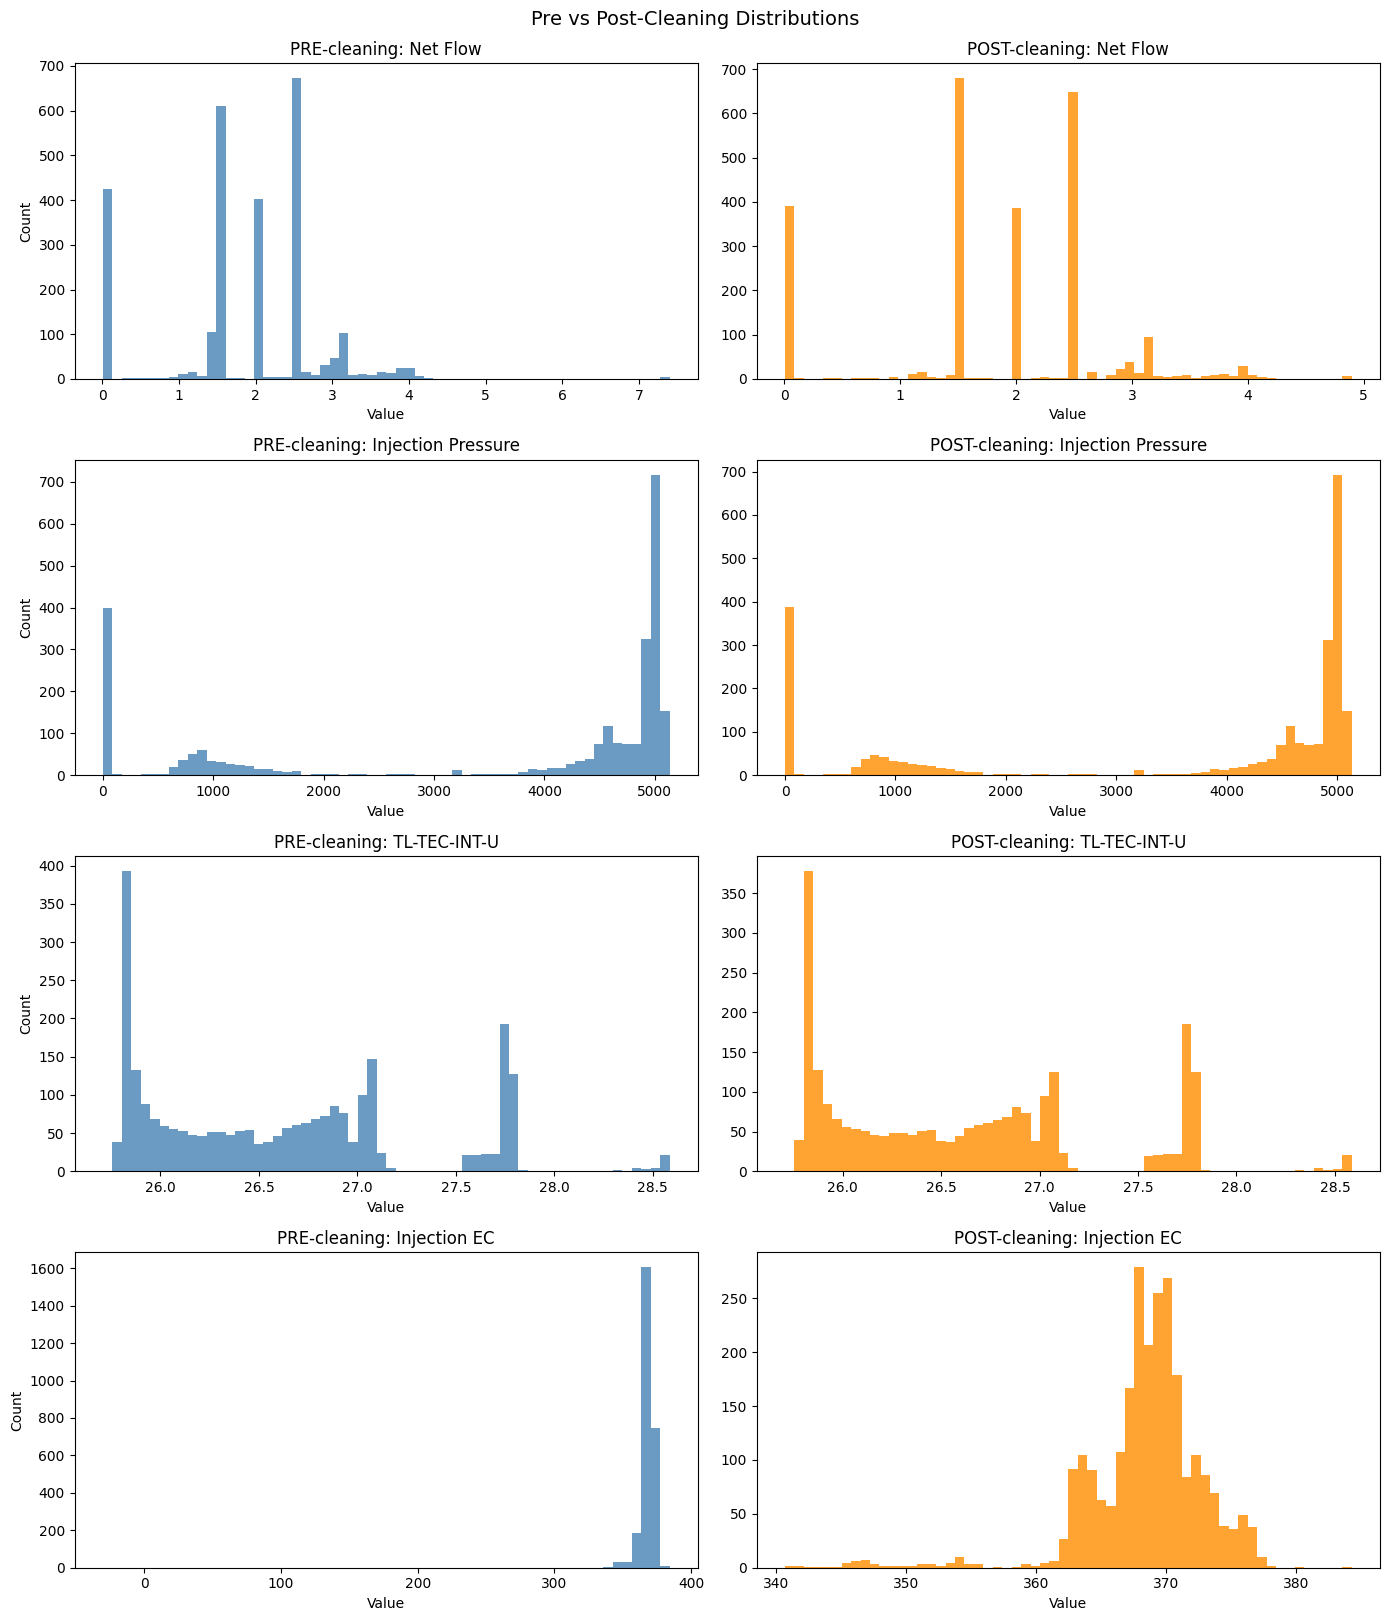

In [14]:
# ── Pre vs post-cleaning distribution plots (key columns) ────────────────────
COLS_TO_PLOT = [
    "Net Flow",
    "Injection Pressure" if "Injection Pressure" in df.columns else pres_cols[0],
    temp_cols[0] if temp_cols else None,
    ec_cols[0]   if ec_cols   else None,
]
COLS_TO_PLOT = [c for c in COLS_TO_PLOT if c and c in df.columns and c in df_raw.columns]

fig, axes = plt.subplots(len(COLS_TO_PLOT), 2, figsize=(14, 4 * len(COLS_TO_PLOT)))
for i, col in enumerate(COLS_TO_PLOT):
    ax_pre, ax_post = axes[i]
    ax_pre.hist(df_raw[col].dropna(), bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    ax_pre.set_title(f"PRE-cleaning: {col}")
    ax_pre.set_xlabel("Value")
    ax_pre.set_ylabel("Count")

    ax_post.hist(df[col].dropna(), bins=60, color="darkorange", edgecolor="none", alpha=0.8)
    ax_post.set_title(f"POST-cleaning: {col}")
    ax_post.set_xlabel("Value")

plt.tight_layout()
plt.suptitle("Pre vs Post-Cleaning Distributions", y=1.01, fontsize=14)
plt.show()

In [15]:
# ── Save cleaned dataset ──────────────────────────────────────────────────────
out_path = OUTPUT_DIR / "FTES_1hour_cleaned.csv"
df.to_csv(out_path)
print(f"Cleaned dataset saved → {out_path}")
print(f"Final shape: {df.shape}")

Cleaned dataset saved → c:\Users\tanx178\OneDrive - PNNL\2026_AI_competition\data\cleaned\FTES_1hour_cleaned.csv
Final shape: (2596, 79)


In [16]:
# ── Data dictionary ───────────────────────────────────────────────────────────
# Build a reference table of all columns with type, units, and transformations

unit_map = {}
for c in df.columns:
    if "Flow" in c:         unit_map[c] = "L/min"
    elif "Pressure" in c:   unit_map[c] = "psi"
    elif "TEC" in c:        unit_map[c] = "°C"
    elif " EC" in c or c.endswith("EC"):  unit_map[c] = "µS/cm"
    elif "Depth" in c:      unit_map[c] = "ft"
    elif "Phase" in c:      unit_map[c] = "categorical"
    elif c.endswith("_neg_flag"):  unit_map[c] = "binary flag"
    elif "Flag" in c:       unit_map[c] = "binary"
    else:                   unit_map[c] = "—"

transform_map = {}
for c in df.columns:
    transforms = []
    if c in flow_cols:   transforms.append("clipped negative→0")
    if c in pres_cols:   transforms.append("clipped <-5psi→0")
    if c in temp_cols:   transforms.append("clipped 0–100°C")
    if c in ec_cols:     transforms.append("negatives flagged (HITL)")
    if c in depth_cols:  transforms.append("zeros→median; z-score cap")
    if c in scale_cols:  transforms.append("MinMaxScaled")
    if c == "Phase":     transforms.append("one-hot encoded (separate cols)")
    transform_map[c] = "; ".join(transforms) if transforms else "None"

data_dict = pd.DataFrame({
    "Column"       : df.columns,
    "dtype"        : [str(df[c].dtype) for c in df.columns],
    "Units"        : [unit_map.get(c, "—") for c in df.columns],
    "Transformations": [transform_map.get(c, "None") for c in df.columns],
    "Non-null count": [df[c].notna().sum() for c in df.columns],
})

dict_path = OUTPUT_DIR / "data_dictionary.csv"
data_dict.to_csv(dict_path, index=False)
print(f"Data dictionary saved → {dict_path}")
data_dict

Data dictionary saved → c:\Users\tanx178\OneDrive - PNNL\2026_AI_competition\data\cleaned\data_dictionary.csv


,Column,dtype,Units,Transformations,Non-null count
0,Injection EC,float64,µS/cm,negatives flagged (HITL); MinMaxScaled,2499
1,Net Flow,float64,L/min,clipped negative→0; MinMaxScaled,2499
2,TL Interval Flow,float64,L/min,clipped negative→0; MinMaxScaled,2499
3,TL Bottom Flow,float64,L/min,clipped negative→0; MinMaxScaled,2499
4,TL Collar Flow,float64,L/min,clipped negative→0; MinMaxScaled,2499
...,...,...,...,...,...
74,Pressure_Differential,float64,psi,MinMaxScaled,2499
75,Depth_Consistency_Flag,int64,ft,None,2596
76,Phase_Ambient Injection,bool,categorical,None,2596
77,Phase_Hot Injection,bool,categorical,None,2596
